# Define SVM ?

Is also mainly used for classification.

Its goal is different:

It finds the best separating line (hyperplane) between classes.

Class A  o  o  o

           |
           |  <- best boundary (maximum
           
           margin)
           |
Class B  x  x  x


So SVM focuses on maximizing the margin between classes.

Both are classification algorithms:

Logistic Regression → classification

Support Vector Machine → classification

But they work differently internally.

✅ Simple summary

Logistic Regression → predicts probability

SVM → finds best separating boundary

# Code

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from  scipy import stats

import seaborn as sns

# Working with perfectly linear_dataset

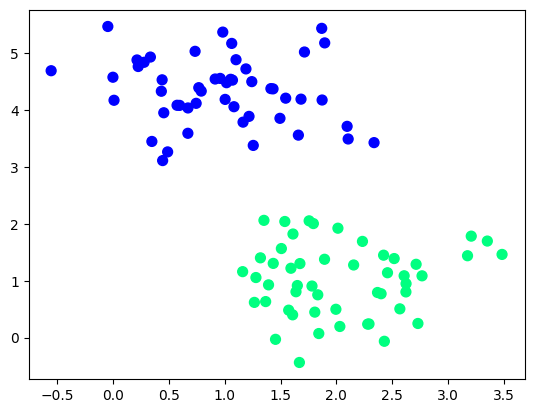

In [27]:
from sklearn.datasets import make_blobs
X,y = make_blobs(n_samples=100, centers=2, random_state=0, cluster_std=0.60)
plt.scatter(X[:, 0],X[:,1],c=y,s=50,cmap='winter')

In [28]:
from sklearn.svm import SVC # 'Support vector classifier'
model = SVC(kernel='linear',C=1) # C = bydefault value
model.fit(X,y)

SVC(C=1, kernel='linear')

In [29]:
def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plot the decision function for a 2D SVC"""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # plot decision boundary and margins
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)


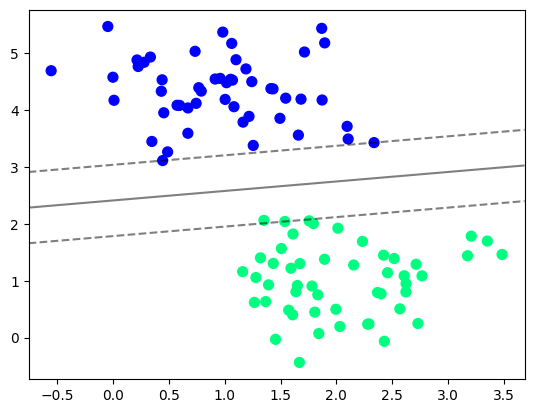

In [30]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
plot_svc_decision_function(model);

# The importance of support vector

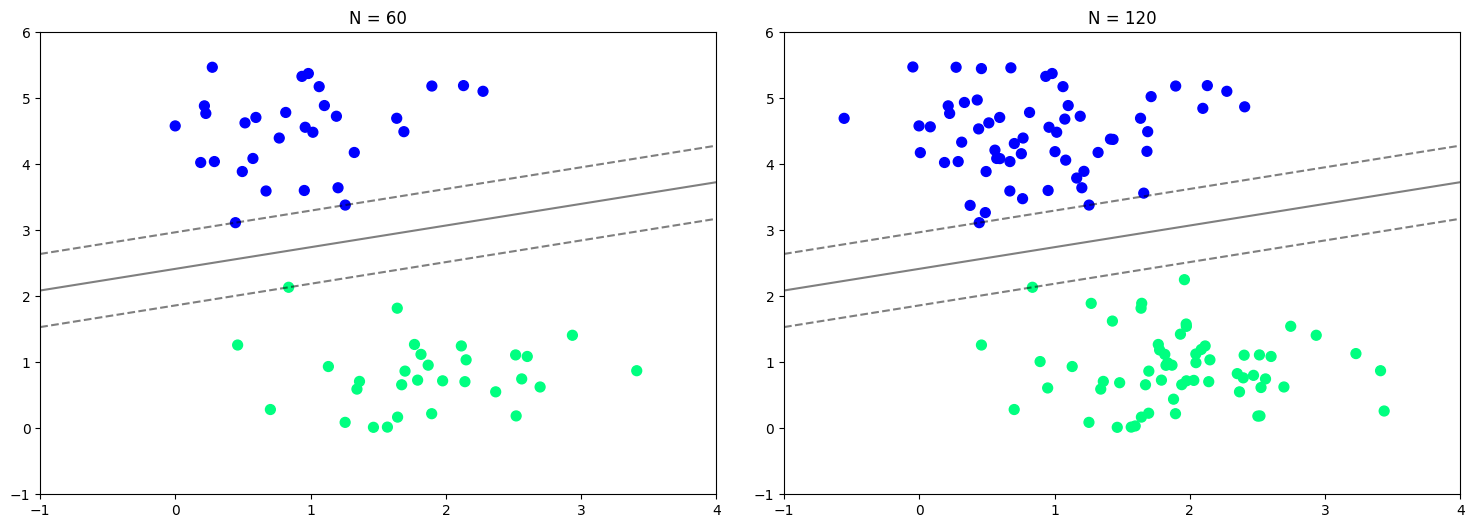

In [31]:
def plot_svm(N=10, ax=None):
    X, y = make_blobs(n_samples=200, centers=2,
                      random_state=0, cluster_std=0.60)
    X = X[:N]
    y = y[:N]
    model = SVC(kernel='linear', C=1E10)
    model.fit(X, y)

    ax = ax or plt.gca()
    ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
    ax.set_xlim(-1, 4)
    ax.set_ylim(-1, 6)
    plot_svc_decision_function(model, ax)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)
for axi, N in zip(ax, [60, 120]):
    plot_svm(N, axi)
    axi.set_title('N = {0}'.format(N))

# Working with Almost Linearly Separable Dataset

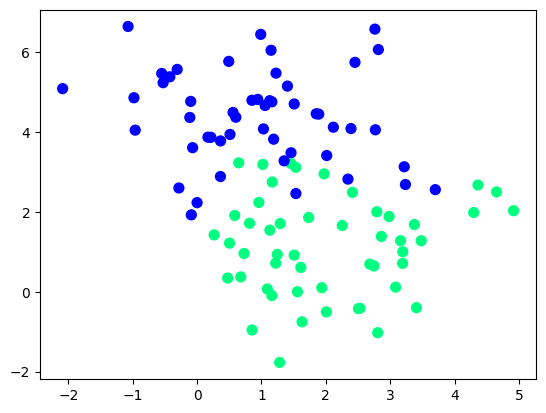

In [32]:
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=1.2)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter');

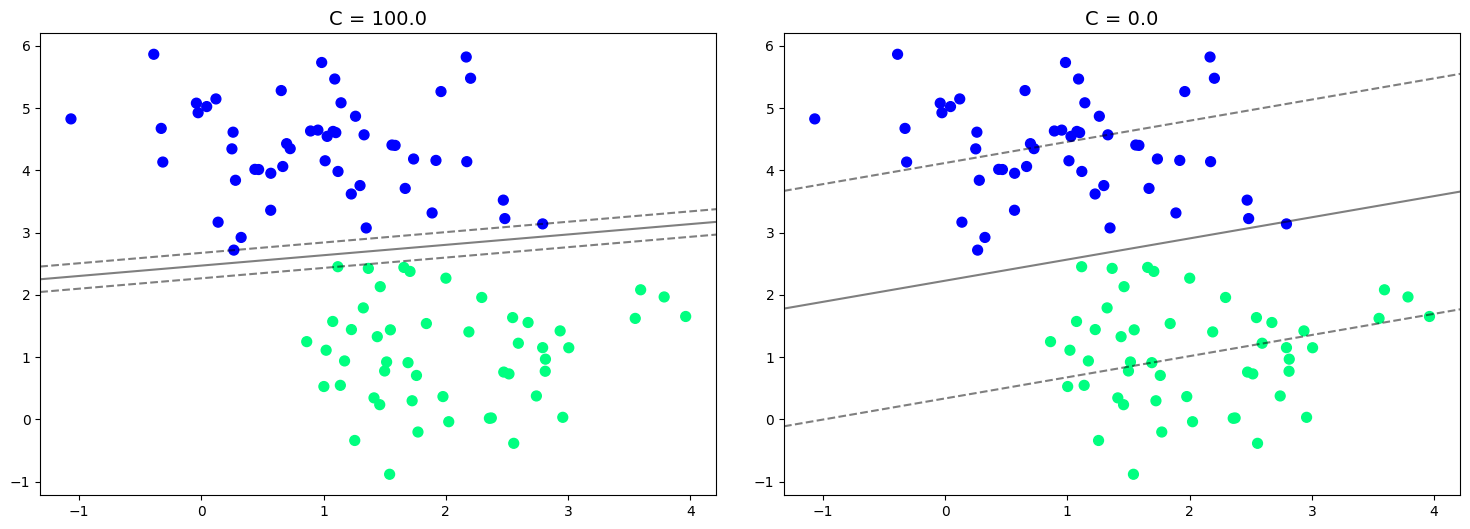

In [33]:
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=0.8)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

for axi, C in zip(ax, [100.0, 0.01]):
    model = SVC(kernel='linear', C=C).fit(X, y)
    axi.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
    plot_svc_decision_function(model, axi)
    axi.scatter(model.support_vectors_[:, 0],
                model.support_vectors_[:, 1],
                s=300, lw=1, facecolors='none');
    axi.set_title('C = {0:.1f}'.format(C), size=14)


# Kernel

Kernel trick ek smart shortcut hai jo data ko higher dimension me map karta hai bina actually transform kiye.

👉 Simple words:
"Data ko upar dimension me le jaake easy separation possible bana deta hai"

🔹 Important Point

Normally agar hum data ko high dimension me convert kare:

Computation heavy hota hai 😵

👉 Kernel trick kya karta hai?

Direct transformation nahi karta

Sirf dot product calculate karta hai smart way se

👉 Kernel trick SVM ko non-linear problems solve karne layak banata hai

# 🔹 Common Kernels

1. Linear Kernel

👉 Jab data already linearly separable ho

K(x, y) = x · y

2. Polynomial Kernel

👉 Jab thoda complex boundary chahiye

K(x, y) = (x · y + 1)^d

3. RBF (Radial Basis Function) Kernel 🔥 (Most popular)

👉 Jab data highly non-linear ho

K(x, y) = exp(-γ ||x - y||²)

# Code


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

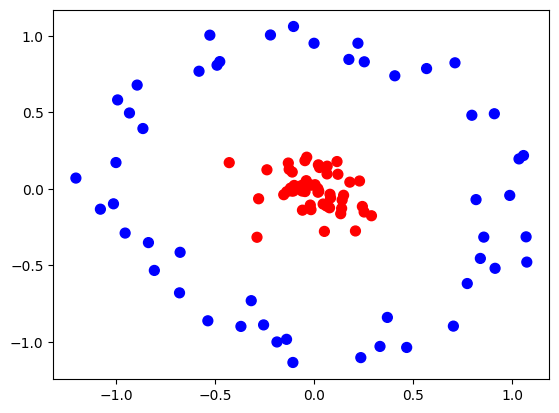

In [35]:
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='bwr')

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

In [37]:
classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train.ravel())
y_pred = classifier.predict(X_test)

In [38]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.4

In [39]:
zero_one_colourmap = ListedColormap(('blue', 'red'))
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1,
                                 stop = X_set[:, 0].max() + 1,
                                 step = 0.01),
                       np.arange(start = X_set[:, 1].min() - 1,
                                 stop = X_set[:, 1].max() + 1,
                                 step = 0.01))

    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(),
                                             X2.ravel()]).T).reshape(X1.shape),
               alpha = 0.75,
               cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = (zero_one_colourmap)(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

/tmp/ipykernel_379/3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


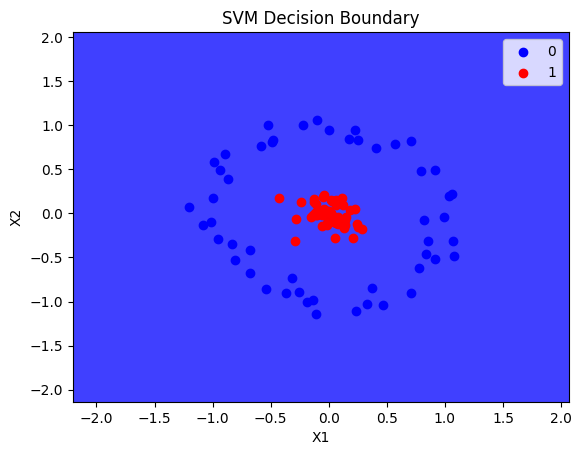

In [40]:
plot_decision_boundary(X, y, classifier)

In [41]:
def plot_3d_plot(X, y):
    r = np.exp(-(X ** 2).sum(1))
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

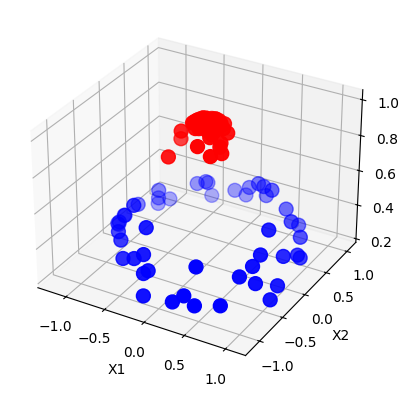

In [42]:
plot_3d_plot(X,y)

In [43]:
rbf_classifier = SVC(kernel="rbf")
rbf_classifier.fit(X_train, y_train)
y_pred = rbf_classifier.predict(X_test)

In [44]:
accuracy_score(y_test, y_pred)

1.0

/tmp/ipykernel_379/3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


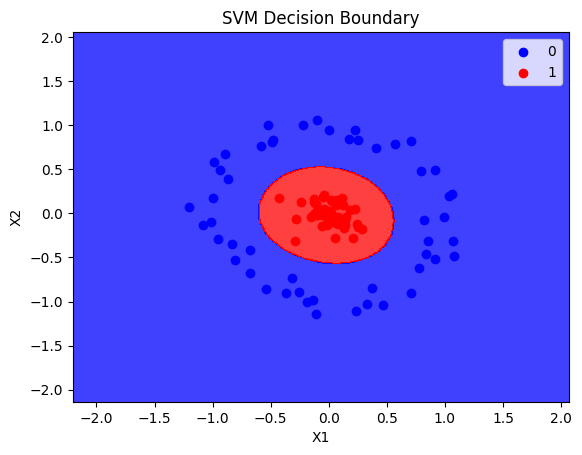

In [45]:
plot_decision_boundary(X, y, rbf_classifier)

In [46]:
poly_classifier = SVC(kernel="poly",degree=2)
poly_classifier.fit(X_train, y_train)
y_pred = poly_classifier.predict(X_test)

In [47]:
accuracy_score(y_test, y_pred)

1.0

/tmp/ipykernel_379/3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


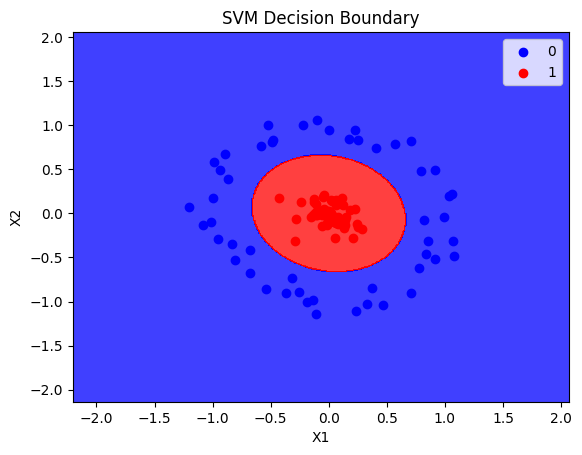

In [48]:
plot_decision_boundary(X, y, poly_classifier)

In [49]:
X
np.exp(-(X**2)).sum(1)

array([1.98633187, 1.31423776, 1.98959289, 1.49005528, 1.98793641,
       1.99814697, 1.96480302, 1.08788367, 1.97716751, 1.38416158,
       1.99217575, 1.97406355, 1.97613185, 1.98342283, 1.9808042 ,
       1.95552283, 1.95567204, 1.27394417, 1.96844802, 1.22329852,
       1.31718218, 1.98832123, 1.26348294, 1.23051268, 1.94597132,
       1.44006508, 1.98944423, 1.97663106, 1.36065298, 1.80383999,
       1.92871358, 1.29870731, 1.99927909, 1.24063518, 1.37435402,
       1.99762485, 1.97847133, 1.322111  , 1.30790653, 1.25993876,
       1.82477059, 1.50674732, 1.11035651, 1.99570851, 1.97539788,
       1.989042  , 1.97458956, 1.99569245, 1.42651534, 1.3388879 ,
       1.99915244, 1.91504165, 1.08234357, 1.22510754, 1.95550265,
       1.34889866, 1.92985166, 1.98722861, 1.99926125, 1.14431456,
       1.1963136 , 1.95704018, 1.97543649, 1.96590742, 1.22267844,
       1.28042179, 1.33054132, 1.3569323 , 1.24149154, 1.32365919,
       1.88854485, 1.92043452, 1.26425931, 1.98129477, 1.98598

In [50]:
np.exp(-(X**2)).sum(1)

array([1.98633187, 1.31423776, 1.98959289, 1.49005528, 1.98793641,
       1.99814697, 1.96480302, 1.08788367, 1.97716751, 1.38416158,
       1.99217575, 1.97406355, 1.97613185, 1.98342283, 1.9808042 ,
       1.95552283, 1.95567204, 1.27394417, 1.96844802, 1.22329852,
       1.31718218, 1.98832123, 1.26348294, 1.23051268, 1.94597132,
       1.44006508, 1.98944423, 1.97663106, 1.36065298, 1.80383999,
       1.92871358, 1.29870731, 1.99927909, 1.24063518, 1.37435402,
       1.99762485, 1.97847133, 1.322111  , 1.30790653, 1.25993876,
       1.82477059, 1.50674732, 1.11035651, 1.99570851, 1.97539788,
       1.989042  , 1.97458956, 1.99569245, 1.42651534, 1.3388879 ,
       1.99915244, 1.91504165, 1.08234357, 1.22510754, 1.95550265,
       1.34889866, 1.92985166, 1.98722861, 1.99926125, 1.14431456,
       1.1963136 , 1.95704018, 1.97543649, 1.96590742, 1.22267844,
       1.28042179, 1.33054132, 1.3569323 , 1.24149154, 1.32365919,
       1.88854485, 1.92043452, 1.26425931, 1.98129477, 1.98598

In [51]:
X_new=np.exp(-(X**2))

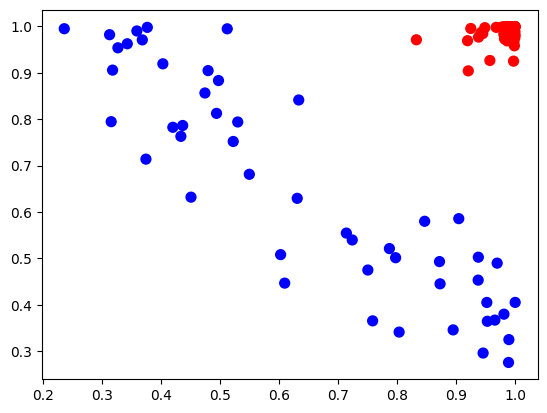

In [52]:
plt.scatter(X_new[:, 0], X_new[:, 1], c=y, s=50, cmap='bwr')
